# 18 — EMA Justification

EMA (`ema_decay=0.999`) has been hardcoded on in `Trainer` since the Sweep A-F
restructuring, but until now `metrics.csv` only ever logged the EMA-swapped
validation metrics — there was no way to see what raw (non-EMA) weights would
have scored, so nothing in the repo actually demonstrated EMA helps.

`src/training/trainer.py` now also validates with raw weights every epoch
(right after `train_epoch`, before the EMA swap) and logs `val_loss_raw`,
`val_rmse_raw`, `val_pearson_r_raw` alongside the existing EMA columns —
purely additive, checkpoint selection is unchanged (`best_model.pt` still
picked on EMA `val_loss`).

`phase_h`'s two runs (`attention_444_multi_200ep`, `distance_444_multi_200ep`,
`subset_protein_data`, the standardized 4/4/4 multi-agg baseline) run for 200
epochs instead of the usual 120 — long enough to see whether raw and EMA val
curves diverge, and whether the recipe itself degrades at a longer horizon
than any other sweep has tested. (An earlier informal 200-epoch run of this
same shape peaked around epoch 73-97 and degraded afterward — see
`sweeps/phase_a_loss_weight.yaml`'s header comment — this is the first time
that's captured with a raw-vs-EMA comparison.)

**Status:** `phase_h` is still running as of this notebook's last execution.
Curves below reflect whatever's completed so far and will fill in further on
re-run.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("../..").resolve()))


## 1. Configuration

In [2]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints" / "phase_h"

RUNS = [
    dict(label="Attention", ckpt_dir=CKPT_ROOT / "attention_444_multi_200ep", color="#2c7fb8"),
    dict(label="Distance",  ckpt_dir=CKPT_ROOT / "distance_444_multi_200ep",  color="#e6550d"),
]

for r in RUNS:
    mpath = r["ckpt_dir"] / "metrics.csv"
    if mpath.exists():
        n_epochs = len(pd.read_csv(mpath))
        print(f"{r['label']:<10}  {n_epochs}/200 epochs so far")
    else:
        print(f"{r['label']:<10}  not started yet")


Attention   25/200 epochs so far
Distance    not started yet


---
## 2. Raw vs. EMA validation curves

Three panels per architecture: val loss, val RMSE, val Pearson r — EMA (solid) vs.
raw (dashed). If EMA is doing its job, the EMA curve should track the raw curve's
trend while being visibly smoother, and should catch up to (or beat) raw once EMA
has had enough epochs to move past its random initialization.

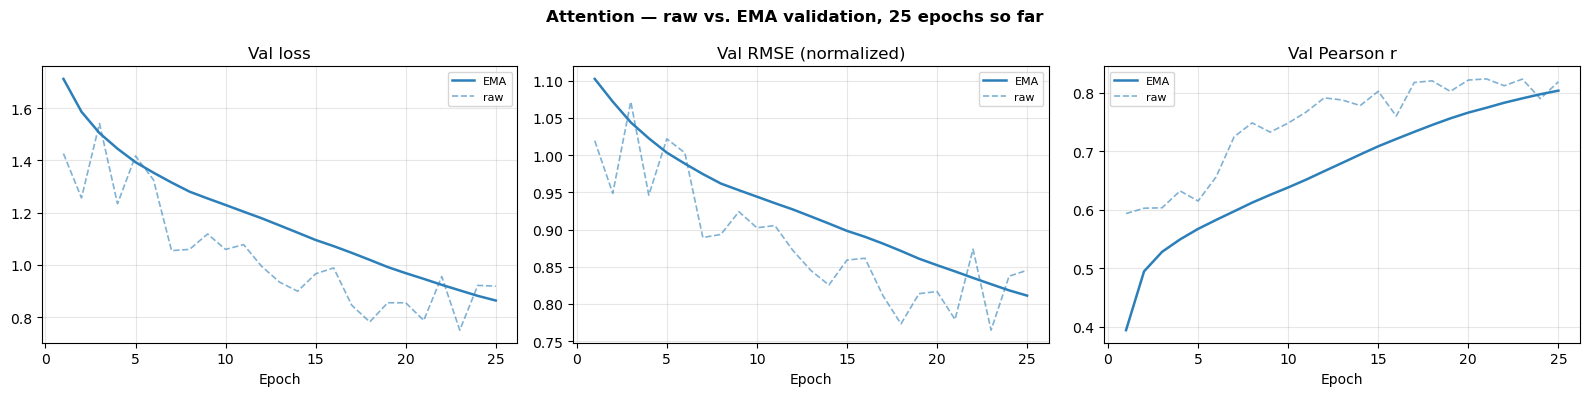

Distance: no metrics.csv yet — skipping


In [3]:
for r in RUNS:
    mpath = r["ckpt_dir"] / "metrics.csv"
    if not mpath.exists():
        print(f"{r['label']}: no metrics.csv yet — skipping")
        continue
    hist = pd.read_csv(mpath)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"{r['label']} — raw vs. EMA validation, {len(hist)} epochs so far",
                 fontweight="bold")

    panels = [
        ("val_loss", "val_loss_raw", "Val loss"),
        ("val_rmse", "val_rmse_raw", "Val RMSE (normalized)"),
        ("val_pearson_r", "val_pearson_r_raw", "Val Pearson r"),
    ]
    for ax, (ema_col, raw_col, title) in zip(axes, panels):
        ax.plot(hist["epoch"], hist[ema_col], "-", color=r["color"], lw=1.8, label="EMA")
        ax.plot(hist["epoch"], hist[raw_col], "--", color=r["color"], lw=1.2, alpha=0.6, label="raw")
        ax.set_xlabel("Epoch")
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


---
## 3. Crossover point

Epoch at which the EMA validation loss first drops below the raw validation loss for
good (i.e. the last epoch where raw was still ahead) — before this point EMA is still
weighed down by the random initial weights it started from; after it, EMA's smoothing
benefit outweighs that lag.

In [4]:
for r in RUNS:
    mpath = r["ckpt_dir"] / "metrics.csv"
    if not mpath.exists():
        continue
    hist = pd.read_csv(mpath)
    ema_ahead = hist["val_loss"] < hist["val_loss_raw"]
    if ema_ahead.any():
        first_ema_ahead = hist.loc[ema_ahead, "epoch"].iloc[0]
        # last epoch where raw was still ahead, if EMA ever falls behind again
        last_raw_ahead = hist.loc[~ema_ahead, "epoch"].max() if (~ema_ahead).any() else None
        print(f"{r['label']}: EMA first ahead of raw at epoch {first_ema_ahead}"
              + (f"  (raw regains lead as late as epoch {last_raw_ahead})" if last_raw_ahead and last_raw_ahead > first_ema_ahead else ""))
    else:
        print(f"{r['label']}: EMA has not caught up to raw yet ({len(hist)} epochs so far)")


Attention: EMA first ahead of raw at epoch 3  (raw regains lead as late as epoch 23)


---
## 4. Decision

*Fill in once both runs complete (200 epochs each).*

| | Attention | Distance |
|---|---|---|
| EMA crossover epoch | ? | ? |
| Best EMA val_loss (epoch) | ? | ? |
| Best raw val_loss (epoch) | ? | ? |
| Does the recipe degrade by epoch 200? | ? | ? |

**Reasoning:** *is EMA's smoothing benefit worth the early-training lag it introduces?
Does the standardized 4/4/4 multi-agg recipe hold up over 200 epochs, or does it show
the same late-stage degradation the earlier informal 200-epoch run showed?*